<a href="https://colab.research.google.com/github/Kayla-afk/Tugas-Kuliah-D4-Sains-Data-Terapan/blob/main/DM_M9_3324600023_Kayla_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LOAD DATASET

In [1]:
import pandas as pd
df = pd.read_csv('/content/transaction.csv')
print(df.head())
print(df.info())

   InvoiceNo  StockCode  Qty      InvoiceDate  CustomerID  Country
0     537626      22725  830  12/7/2010 14:57       12347  Iceland
1     537626      22729  948  12/7/2010 14:57       12347  Iceland
2     537626      22195  695  12/7/2010 14:57       12347  Iceland
3     542237      22725  636  1/26/2011 14:30       12347  Iceland
4     542237      22729  536  1/26/2011 14:30       12347  Iceland
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10546 entries, 0 to 10545
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   InvoiceNo    10546 non-null  int64 
 1   StockCode    10546 non-null  int64 
 2   Qty          10546 non-null  int64 
 3   InvoiceDate  10546 non-null  object
 4   CustomerID   10546 non-null  int64 
 5   Country      10546 non-null  object
dtypes: int64(4), object(2)
memory usage: 494.5+ KB
None


Dataset berhasil dimuat ke dalam DataFrame df untuk memahami struktur data seperti:

* nama kolom
* tipe data
* indikasi missing value

## HITUNG KEMUNCULAN TIAP NEGARA

In [2]:
# Hitung frekuensi kemunculan negara
country_count = df['Country'].value_counts()

# Tampilkan hasil
country_count

,count
Country,
Germany,2269
France,2109
EIRE,1620
Netherlands,634
Spain,539
Belgium,486
Switzerland,434
Portugal,367
Australia,356


* Menggunakan value_counts() untuk melihat distribusi data berdasarkan negara
* Membantu memahami dominasi negara dalam dataset
* Berguna untuk insight awal sebelum clustering

## HITUNG JUMLAH TRANSAKSI PER NEGARA

In [3]:
# Hitung jumlah transaksi unik per negara
transaction_per_country = df.groupby('Country')['InvoiceNo'].nunique()

# Ubah ke DataFrame
transaction_per_country = transaction_per_country.reset_index()
transaction_per_country.columns = ['Country', 'TransactionCount']

transaction_per_country

,Country,TransactionCount
0,Australia,44
1,Austria,12
2,Bahrain,1
3,Belgium,84
4,Brazil,1
5,Canada,3
6,Channel Islands,21
7,Cyprus,16
8,Czech Republic,2
9,Denmark,18


* Menggunakan groupby() + nunique() untuk menghitung transaksi unik
* Merupakan fitur utama untuk clustering
* Dataset sekarang sudah dalam bentuk agregasi dan siap untuk digunakan pada tahap selanjutnya

## CLUSTERING (AVERAGE LINKAGE, k=3)

In [4]:
from scipy.cluster.hierarchy import linkage, fcluster

# Ambil hanya fitur numerik
X = transaction_per_country[['TransactionCount']]

# Hierarchical clustering (average linkage)
Z = linkage(X, method='average')

# Tentukan cluster (k=3)
transaction_per_country['Cluster'] = fcluster(Z, 3, criterion='maxclust')

transaction_per_country

,Country,TransactionCount,Cluster
0,Australia,44,1
1,Austria,12,1
2,Bahrain,1,1
3,Belgium,84,1
4,Brazil,1,1
5,Canada,3,1
6,Channel Islands,21,1
7,Cyprus,16,1
8,Czech Republic,2,1
9,Denmark,18,1


* Menggunakan Hierarchical Clustering (Agglomerative)
* average linkage → jarak antar cluster dihitung dari rata-rata jarak antar anggota
* k=3 → menghasilkan 3 kelompok:
  * rendah
  * sedang
  * tinggi

## MENENTUKAN CENTROID TIAP CLUSTER

In [5]:
# Hitung centroid (rata-rata tiap cluster)
centroids = transaction_per_country.groupby('Cluster')['TransactionCount'].mean().reset_index()

centroids.columns = ['Cluster', 'Centroid']

centroids

,Cluster,Centroid
0,1,18.787879
1,2,360.500000
2,3,224.000000


* Centroid = representasi nilai rata-rata tiap cluster
* Digunakan untuk menentukan urutan (rendah → tinggi)
* Penting dilakukan untuk interpretasi hasil clustering

## URUTKAN CENTROID (ASCENDING)

In [6]:
# Urutkan centroid
sorted_centroids = centroids.sort_values(by='Centroid').reset_index(drop=True)

sorted_centroids

,Cluster,Centroid
0,1,18.787879
1,3,224.000000
2,2,360.500000


* Mengurutkan cluster berdasarkan nilai centroid
* Tujuannya untuk memberi label:
  * kecil = rendah
  * sedang = menengah
  * besar = tinggi

## MAPPING CLUSTER (SEDANG/RENDAH/TINGGI)

In [7]:
# Mapping cluster berdasarkan urutan centroid
cluster_label_map = {}

cluster_label_map[sorted_centroids.iloc[0]['Cluster']] = 'Rendah'
cluster_label_map[sorted_centroids.iloc[1]['Cluster']] = 'Sedang'
cluster_label_map[sorted_centroids.iloc[2]['Cluster']] = 'Tinggi'

# Tambahkan label ke dataset
transaction_per_country['Kategori'] = transaction_per_country['Cluster'].map(cluster_label_map)

transaction_per_country

,Country,TransactionCount,Cluster,Kategori
0,Australia,44,1,Rendah
1,Austria,12,1,Rendah
2,Bahrain,1,1,Rendah
3,Belgium,84,1,Rendah
4,Brazil,1,1,Rendah
5,Canada,3,1,Rendah
6,Channel Islands,21,1,Rendah
7,Cyprus,16,1,Rendah
8,Czech Republic,2,1,Rendah
9,Denmark,18,1,Rendah


* Cluster awal hanya berupa angka (1,2,3)
* Diubah menjadi label yang lebih bermakna:
  * Rendah
  * Sedang
  * Tinggi
* Merupakan tahap interpretasi model (data mining insight)

# Tampilkan Negara berdasarkan Kategori

In [8]:
for kategori in ['Rendah', 'Sedang', 'Tinggi']:
    print(f"\nNegara dengan transaksi {kategori}:")
    print(transaction_per_country[transaction_per_country['Kategori'] == kategori]['Country'].values)


Negara dengan transaksi Rendah:
['Australia' 'Austria' 'Bahrain' 'Belgium' 'Brazil' 'Canada'
 'Channel Islands' 'Cyprus' 'Czech Republic' 'Denmark'
 'European Community' 'Finland' 'Greece' 'Iceland' 'Israel' 'Italy'
 'Japan' 'Lebanon' 'Lithuania' 'Malta' 'Netherlands' 'Norway' 'Poland'
 'Portugal' 'RSA' 'Saudi Arabia' 'Singapore' 'Spain' 'Sweden'
 'Switzerland' 'USA' 'United Arab Emirates' 'Unspecified']

Negara dengan transaksi Sedang:
['EIRE']

Negara dengan transaksi Tinggi:
['France' 'Germany']


* Memberikan insight bisnis:
  * Negara dengan aktivitas rendah
  * Negara potensial
  * Negara dengan performa tinggi

## VISUALISASI CLUSTERING

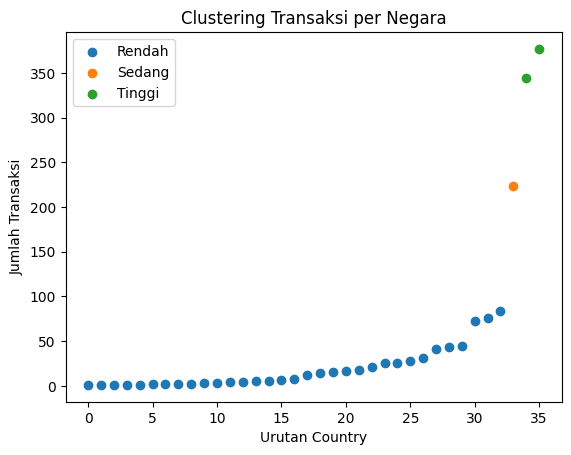

In [9]:
import matplotlib.pyplot as plt

# Urutkan berdasarkan jumlah transaksi
plot_df = transaction_per_country.sort_values(by='TransactionCount').reset_index(drop=True)

# Plot
plt.figure()
for kategori in plot_df['Kategori'].unique():
    subset = plot_df[plot_df['Kategori'] == kategori]
    plt.scatter(subset.index, subset['TransactionCount'], label=kategori)

plt.xlabel('Urutan Country')
plt.ylabel('Jumlah Transaksi')
plt.title('Clustering Transaksi per Negara')
plt.legend()
plt.show()

* Sumbu X = urutan negara
* Sumbu Y = jumlah transaksi
* Warna menunjukkan cluster
* Membantu visualisasi pola distribusi:
  * cluster rendah → titik bawah
  * cluster tinggi → titik atas

## KESIMPULAN
* Dataset berhasil ditransformasikan menjadi data agregasi berbasis negara
* Clustering menggunakan Hierarchical Clustering (Average Linkage) berhasil membagi data menjadi 3 kelompok
* Centroid digunakan untuk interpretasi cluster secara objektif
* Hasil akhir memberikan insight:
  * segmentasi negara berdasarkan aktivitas transaksi